### Постановка задачи

Необходимо провести разведочный анализ датасета Preventive_Care_Flag. Ключевая переменная - Preventive_Care_Flag. Нужно просмотреть все зависимости, особенно у Preventive_Care_Flag.

### Подключение модулей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка данных

In [2]:
df = pd.read_csv('patient_segmentation_dataset.csv')

In [3]:
df.head()

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


### Описание данных

- **PatientID** - ID пациента
- **Age** - Возраст
- **Gender** - Пол
- **State** - Штат США, в котором проживает пациент
- **City** - Город проживания пациента
- **Height_cm** - Рост в сантиметрах
- **Weight_kg** - Вес в килограммах
- **BMI** - Индекс массы тела
- **Insurance_Type** - Вид медицинского страхования
- **Primary_Condition** - Основное состояние здоровья
- **Num_Chronic_Conditions** - Кол-во хронических заболеваний
- **Annual_Visits** - Кол-во визитов за год
- **Avg_Billing_Amount** - Средний счет за посещение (в долларах США)
- **Last_Visit_Date** - Дата последнего визита
- **Days_Since_Last_Visit** - Кол-во прошедших дней с последнего визита
- **Preventive_Care_Flag** - Участвует ли пациент в профилактических мероприятиях (0=Нет, 1=Да)

### Разведочный анализ данных (EDA)

Выведем информацию о колонках датасета

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2000 non-null   object 
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   object 
 3   State                   2000 non-null   object 
 4   City                    2000 non-null   object 
 5   Height_cm               2000 non-null   int64  
 6   Weight_kg               2000 non-null   int64  
 7   BMI                     2000 non-null   float64
 8   Insurance_Type          2000 non-null   object 
 9   Primary_Condition       1505 non-null   object 
 10  Num_Chronic_Conditions  2000 non-null   int64  
 11  Annual_Visits           2000 non-null   int64  
 12  Avg_Billing_Amount      2000 non-null   float64
 13  Last_Visit_Date         2000 non-null   object 
 14  Days_Since_Last_Visit   2000 non-null   

Довольно много пропущенных значений у колонки Primary_Condition, в остальном пропусков нет.

Рассмотрим распределение данных

In [6]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,50.69550,167.907500,85.143500,30.740650,1.080000,5.466500,4000.270500,180.085000,0.464000
std,15.44445,12.684494,20.385428,8.839952,0.890504,3.485965,2463.239215,104.688484,0.498827
min,18.00000,145.000000,50.000000,13.400000,0.000000,1.000000,207.000000,1.000000,0.000000
25%,40.00000,158.000000,67.000000,23.800000,1.000000,3.000000,2061.000000,90.000000,0.000000
50%,51.00000,168.000000,86.000000,30.100000,1.000000,4.000000,3707.250000,183.000000,0.000000
75%,63.25000,177.000000,103.000000,37.025000,1.000000,8.000000,5650.875000,268.000000,1.000000
max,87.00000,195.000000,120.000000,57.100000,3.000000,12.000000,12467.500000,365.000000,1.000000


Каких-либо аномальных значений замечено не было

Построим гистограммы распределения каждого признака (столбца данных)

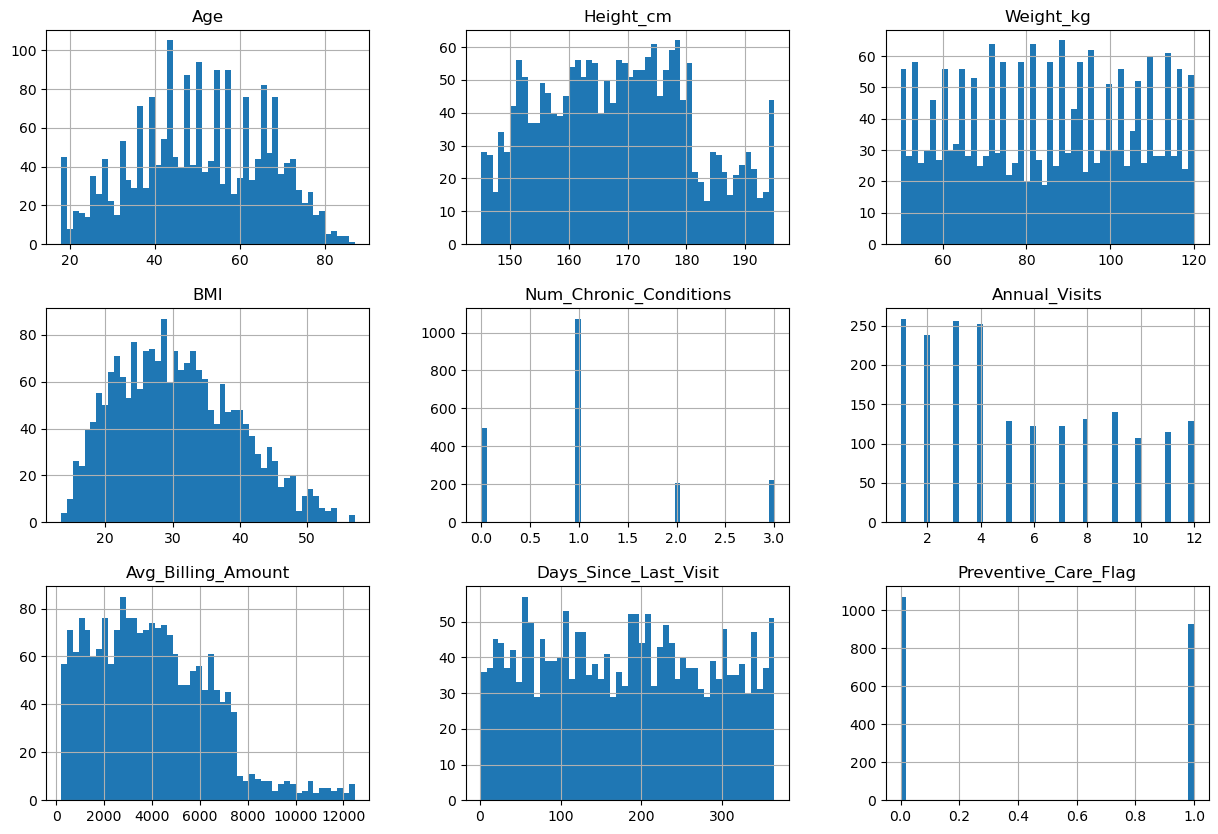

In [8]:
df.hist(figsize = (15,10), bins = 50);

У колонок Avg_Billing_Amount, Height_cm, BMI, Annual_Visits, Num_Chronic_Conditions есть перевес распределения в левую сторону. У остальных колонок распределение нормальное.

Рассмотрим, сколько мужчин и сколько женщин находится на стационаре

In [9]:
df["Gender"].value_counts()

Gender
Female    1001
Male       999
Name: count, dtype: int64

Почти равное количество.

Посмотрим распределение по штатам.

In [10]:
df["State"].value_counts()

State
NC    213
GA    211
CA    209
OH    208
IL    205
NY    196
TX    195
MI    191
PA    189
FL    183
Name: count, dtype: int64

Больше всего людей на стационаре в штате Северная Каролина. В остальных штатах кол-во уменьшается постепенно.

Построим попарные зависимости признаков

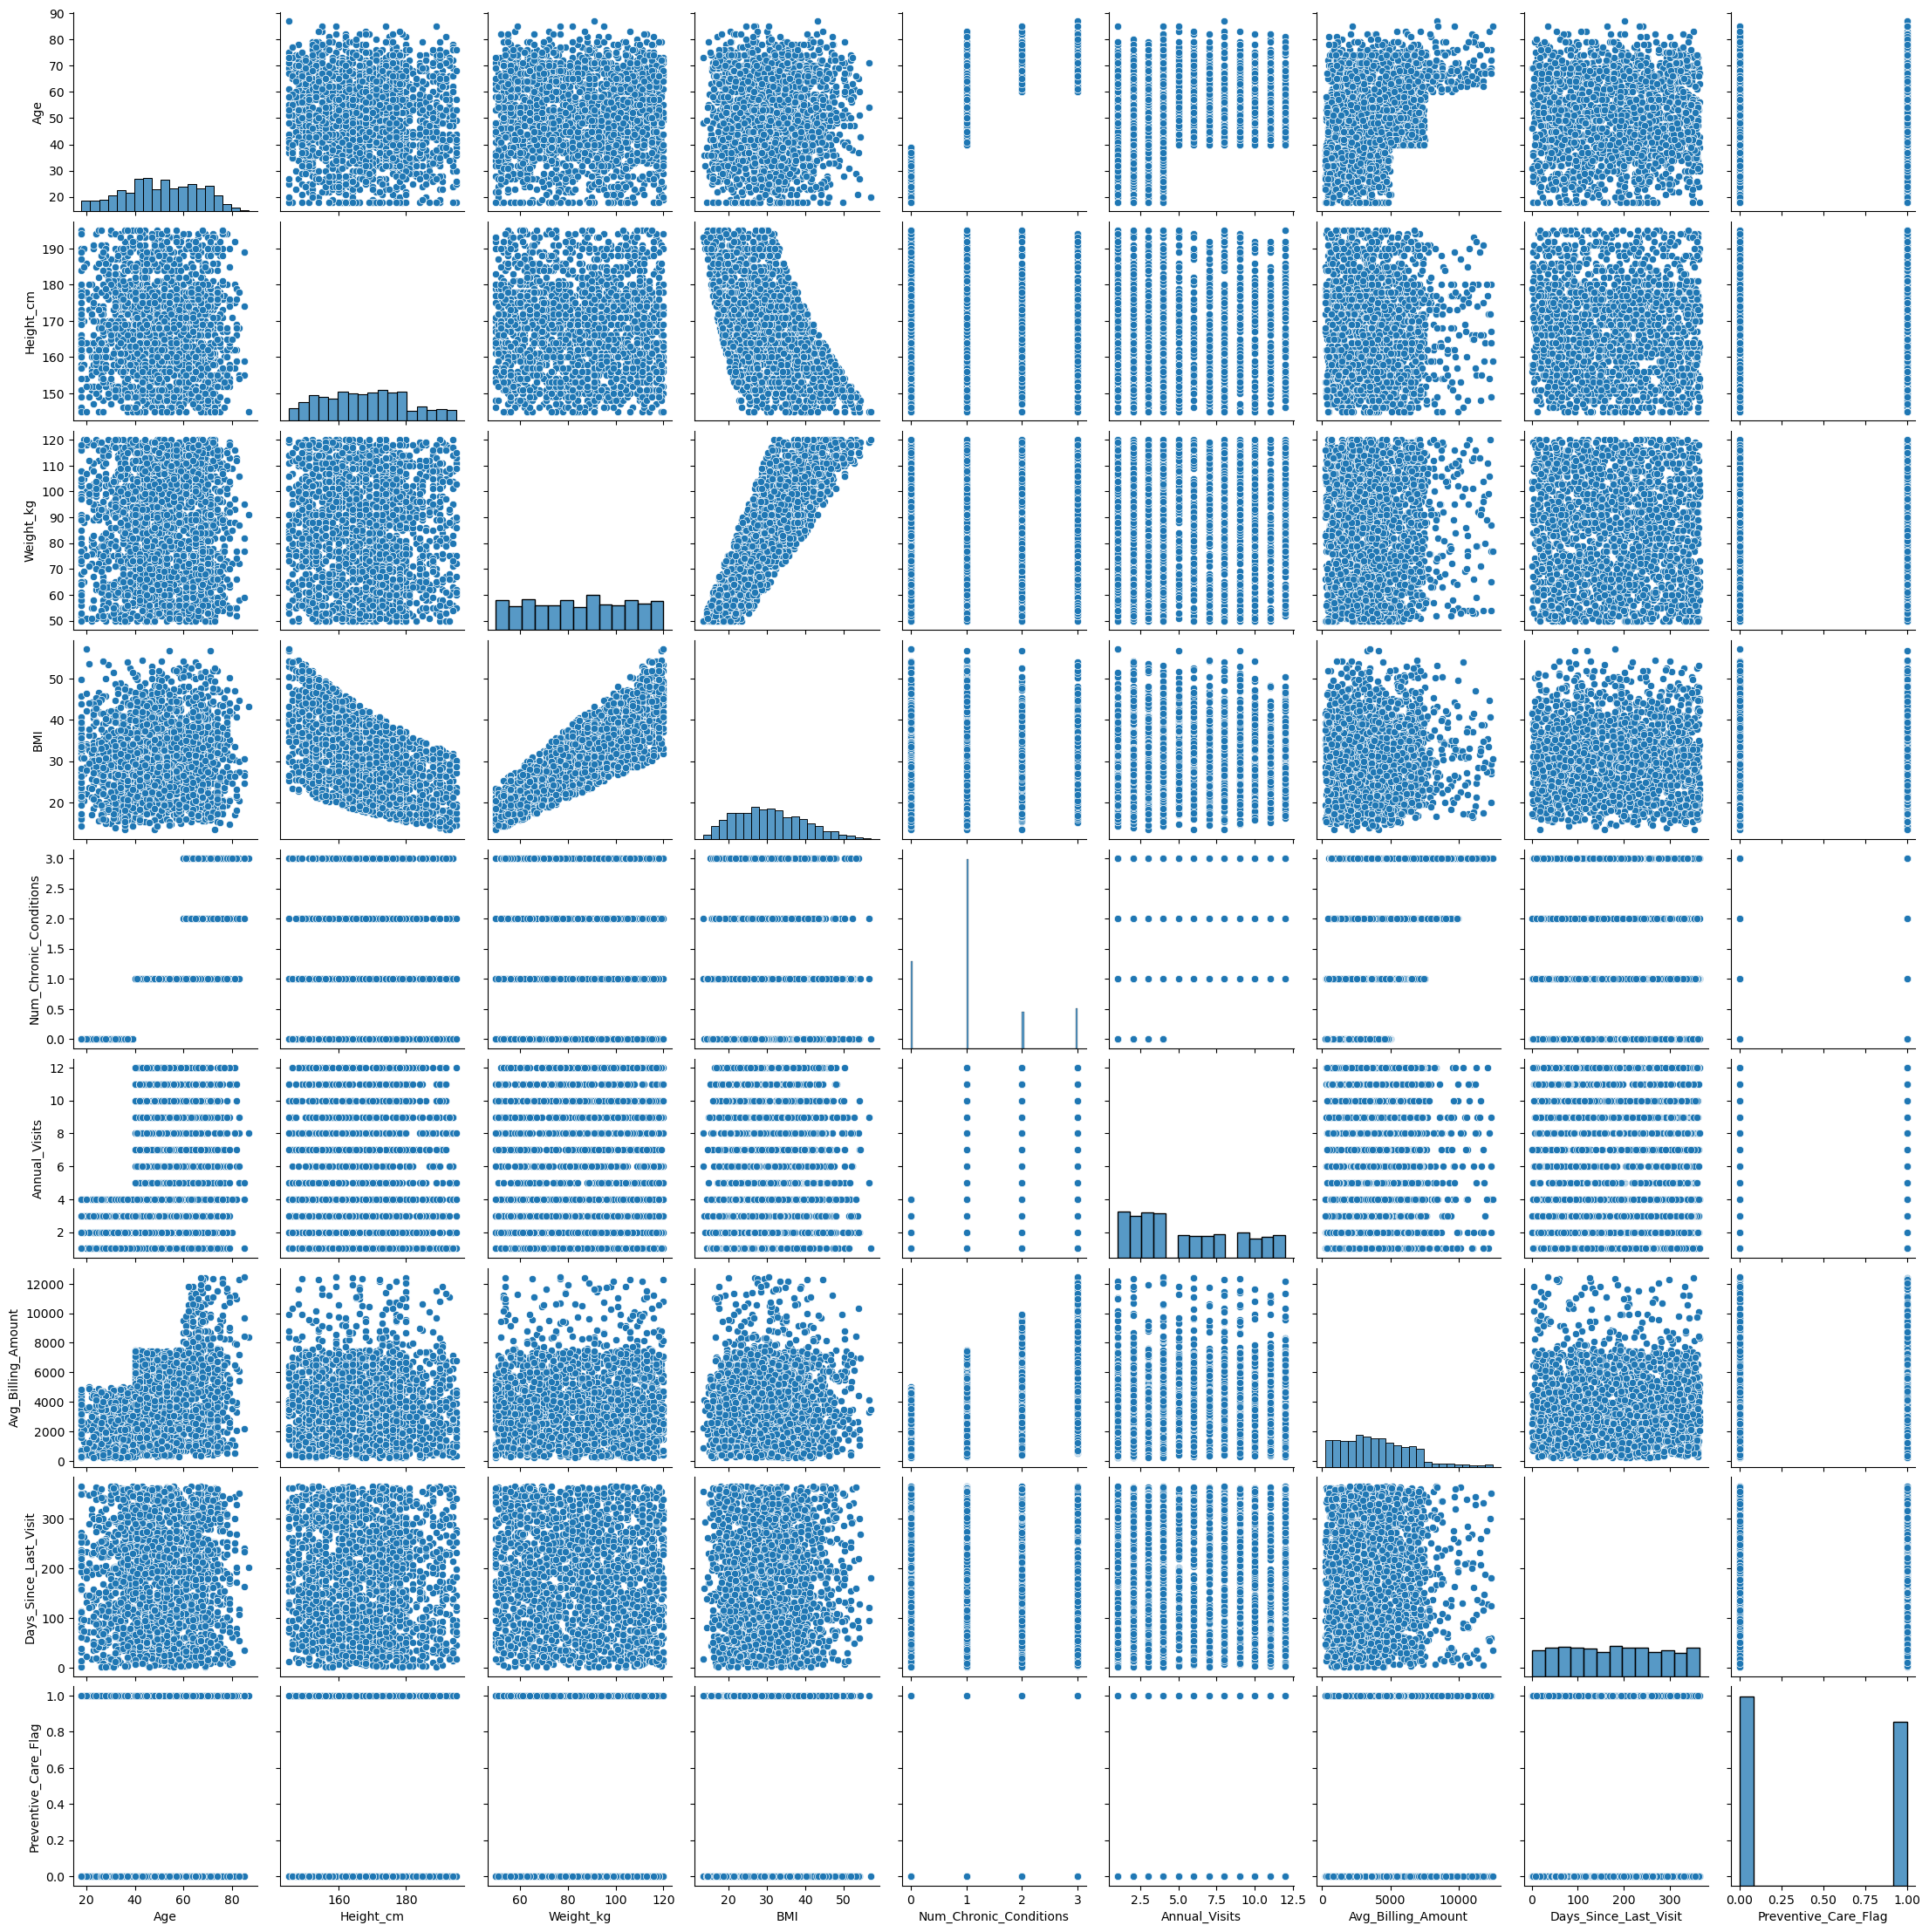

In [12]:
sns.pairplot(df[["Age", "Gender", "State", "City", "Height_cm", "Weight_kg", "BMI", "Primary_Condition", "Num_Chronic_Conditions", "Annual_Visits", "Avg_Billing_Amount", "Days_Since_Last_Visit", "Preventive_Care_Flag"]])

У всех довольно разное распределение

 Рассмотрим, как штаты влияют на возраст

<Axes: xlabel='State', ylabel='Age'>

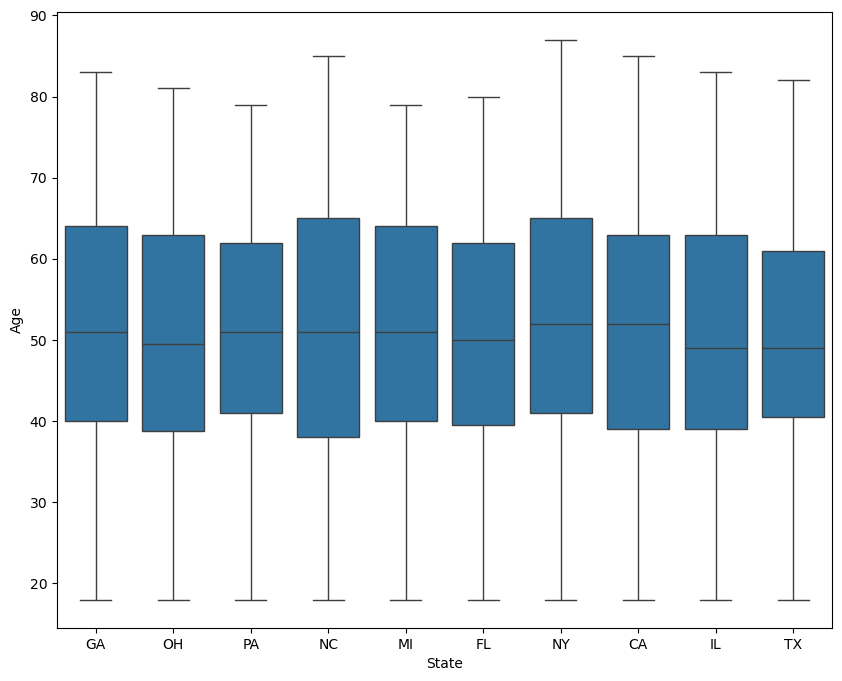

In [14]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='State', y='Age', data = df)

Зависимостей замечено не было, везде более-менее равное распределение

Посмотрим сколько людей учавствуют в профилактических мероприятиях

<Axes: xlabel='Preventive_Care_Flag', ylabel='count'>

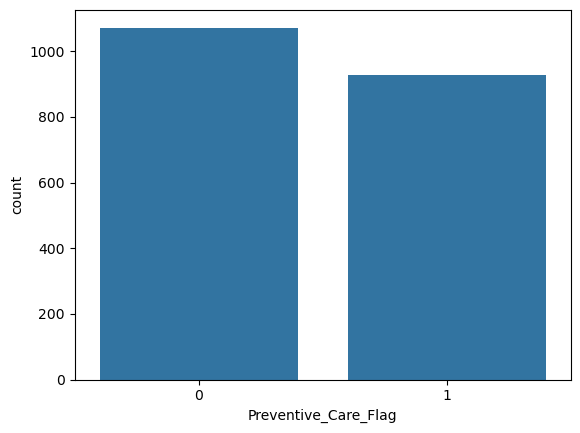

In [15]:
sns.countplot(x = 'Preventive_Care_Flag', data = df)

Немного преобладают люди, которые не учавствуют в мероприятиях

Рассмотрим влия

<Axes: xlabel='Preventive_Care_Flag', ylabel='count'>

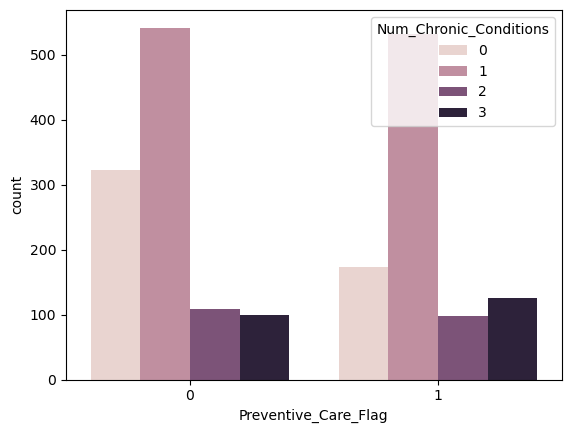

In [16]:
sns.countplot(data = df, x ="Preventive_Care_Flag", hue = "Num_Chronic_Conditions")

Единственное сильное отличие - при 0 хронических заболеваний люди меньше учавствуют в мероприятиях. Почти все остальные параметры равны в обоих случаях.

### Корреляционный анализ

In [17]:
corr = df.corr(numeric_only=True)
corr

,Age,Height_cm,Weight_kg,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag
Age,1.000000,-0.018662,0.026305,0.030859,0.797068,0.366565,0.350142,0.023148,0.118994
Height_cm,-0.018662,1.000000,-0.016844,-0.535225,-0.016927,-0.039514,-0.011952,-0.032195,-0.019620
Weight_kg,0.026305,-0.016844,1.000000,0.842057,0.034723,0.030714,0.037475,-0.029076,0.008109
BMI,0.030859,-0.535225,0.842057,1.000000,0.032180,0.040556,0.032210,-0.003841,0.015834
Num_Chronic_Conditions,0.797068,-0.016927,0.034723,0.032180,1.000000,0.336860,0.425172,0.027755,0.113472
Annual_Visits,0.366565,-0.039514,0.030714,0.040556,0.336860,1.000000,0.125944,-0.010451,0.073097
Avg_Billing_Amount,0.350142,-0.011952,0.037475,0.032210,0.425172,0.125944,1.000000,0.001400,0.036312
Days_Since_Last_Visit,0.023148,-0.032195,-0.029076,-0.003841,0.027755,-0.010451,0.001400,1.000000,0.014830
Preventive_Care_Flag,0.118994,-0.019620,0.008109,0.015834,0.113472,0.073097,0.036312,0.014830,1.000000


<Axes: >

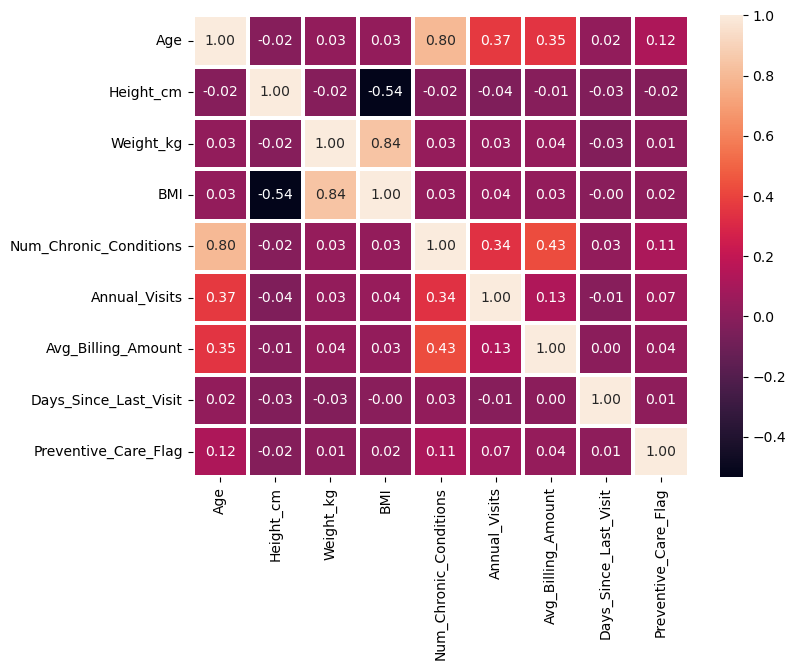

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot = True, linewidths=1.5 , fmt = '.2f')

Самые явные зависимости: ИМТ от роста и веса, кол-во хронических заболеваний от возраста. Также есть зависимости поменьше: у Annual_Visits и Avg_Billing_Amount зависимость от Age и от Num_Chronic_Conditions. У ключевой переменной зависимостей не обнаружено. 

### Вывод

У ключевой переменной, за которую мы взяли Preventive_Care_Flag, зависимостей замечено не было. Явные зависимости были замечены у других переменных.